# Progetto finale del corso
## Problema A: Inquinamento atmosferico

In [1]:
import numpy as np 
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

import json

from pathlib import Path
from shapely.geometry import Point
from shapely.geometry import shape

# c'è anche da importare sklearn

In [2]:
data_path = Path('../data/raw')

files = {'grid':'trentino-grid.geojson',
         'adm_reg':'administrative_regions_Trentino.json',
         'weather':'meteotrentino-weather-station-data.json',
         'precip':'precipitation-trentino.csv',
         'precip-avail':'precipitation-trentino-data-availability.csv',
         'SET-1':'SET-nov-2013.csv',
         'SET-2':'SET-dec-2013.csv',
         'SET-lines':'line.csv',
         'twitter':'social-pulse-trentino.geojson'}

df_grid = gpd.read_file(data_path / files['grid'])

<Axes: >

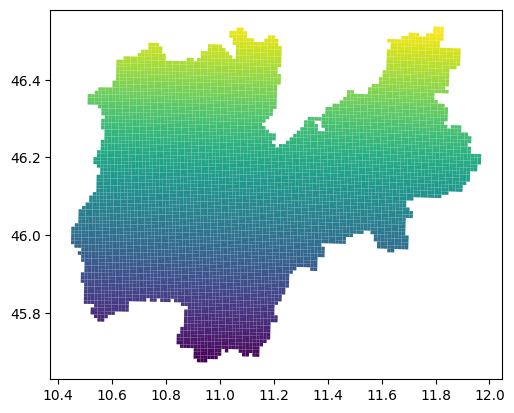

In [3]:
df_grid.plot('cellId') 

In [4]:
'''   Mancano dati e comunque è inutile )= (
with open(data_path / files['adm_reg']) as f:
    adm_reg_json = json.load(f)

adm_reg = gpd.GeoDataFrame(adm_reg_json['items'])

# convert GeoJSON dicts to shapely geometries
adm_reg['geometry'] = adm_reg['geometry'].apply(shape)

# set geometry column
adm_reg = adm_reg.set_geometry('geometry')
for i, geom in enumerate(adm_reg['geometry']):
    try:
        shape(geom)
    except Exception as e:
        print(f"Row {i}: {e}")
        print(geom)
        break


SyntaxError: incomplete input (542241798.py, line 1)

In [5]:
with open(data_path / files['weather']) as f:
    weather_json = json.load(f)

weather = gpd.GeoDataFrame(weather_json['features'])
# weather[weather['station'] == 'T0071'][['precipitations.0000', 'precipitations.0015', 'precipitations.0030', 'precipitations.0045']]
weather

,station,geomPoint.geom,elevation,date,timestamp,minTemperature,maxTemperature,precipitation,minWind,maxWind,...,winds.2130,winds.2145,winds.2200,winds.2215,winds.2230,winds.2245,winds.2300,winds.2315,winds.2330,winds.2345
0,T0071,"{'type': 'Point', 'coordinates': [10.79582897,...",905,2013-11-01,1383260400,4.5,12.3,False,0.0,2.5,...,0@183,,0@157,,0.4@228,0.3@248,,0@201,0@199,
1,T0032,"{'type': 'Point', 'coordinates': [11.25371981,...",1155,2013-11-01,1383260400,6.5,10.2,False,NaN,NaN,...,,,,,,,,,,
2,T0096,"{'type': 'Point', 'coordinates': [11.6645808, ...",1205,2013-11-01,1383260400,6.5,11.8,False,NaN,NaN,...,,,,,,,,,,
3,T0074,"{'type': 'Point', 'coordinates': [10.91841055,...",720,2013-11-01,1383260400,6.2,13.6,False,0.0,4.8,...,0.3@198,0.3@196,0.4@236,,0.9@15,0.6@345,1@244,0.5@192,0@157,
4,T0101,"{'type': 'Point', 'coordinates': [11.07973339,...",201,2013-11-01,1383260400,11.1,16.3,False,NaN,NaN,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190,T0431,"{'type': 'Point', 'coordinates': [11.33626355,...",1055,2013-12-31,1388444400,-5.5,0.5,False,NaN,NaN,...,,,,,,,,,,
2191,T0428,"{'type': 'Point', 'coordinates': [10.64240944,...",525,2013-12-31,1388444400,-2.2,6.9,False,NaN,NaN,...,,,,,,,,,,
2192,T0437,"{'type': 'Point', 'coordinates': [11.76685208,...",1465,2013-12-31,1388444400,-9.9,-2.4,False,0.1,2.5,...,0.6@114,1@113,1.3@105,1.1@115,0.9@113,1@115,1.4@110,1.4@98,1.5@109,1.5@106
2193,T0469,"{'type': 'Point', 'coordinates': [11.6299111, ...",801,2013-12-31,1388444400,-4.1,2.7,False,0.1,1.4,...,0.7@38,0.7@83,0.3@148,,0.8@35,0.5@349,0.7@340,0.4@353,0.8@353,0.7@15


<Axes: >

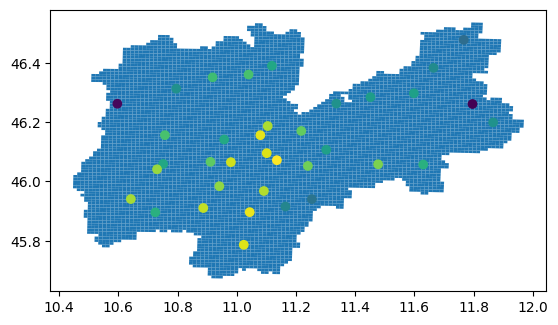

In [8]:
time_mask = (weather['timestamp'] == 1383260400)
ax = df_grid.plot()
weather[time_mask].plot(column='temperatures.0000',ax=ax)

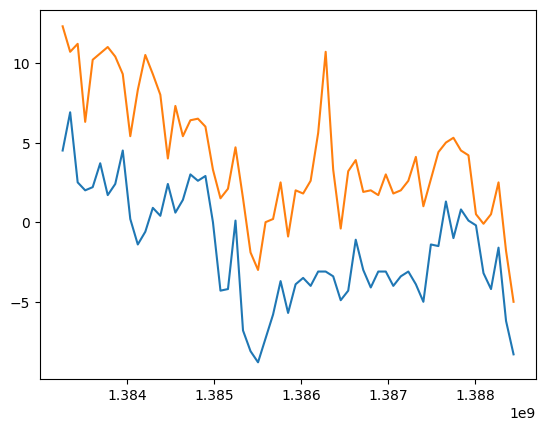

In [9]:
station_mask = (weather['station'] == 'T0071')

plt.plot('timestamp', 'minTemperature', data=weather[station_mask])
plt.plot('timestamp', 'maxTemperature', data=weather[station_mask])

In [10]:
winds_cols = [c for c in weather.columns if c.startswith("winds.")]

new_cols = []

for c in winds_cols:

    split_cols = weather[c].str.split("@", n=1, expand=True)

    # ensure two columns always exist
    split_cols = split_cols.reindex(columns=[0, 1])

    split_cols.columns = [f"{c}_spd", f"{c}_dir"]

    split_cols = split_cols.apply(pd.to_numeric, errors="coerce")

    new_cols.append(split_cols)

weather = pd.concat([weather] + new_cols, axis=1)




In [11]:
weather.drop(columns=winds_cols,inplace=True)
weather

,station,elevation,date,timestamp,minTemperature,maxTemperature,precipitation,minWind,maxWind,temperatures.0000,...,winds.2245_spd,winds.2245_dir,winds.2300_spd,winds.2300_dir,winds.2315_spd,winds.2315_dir,winds.2330_spd,winds.2330_dir,winds.2345_spd,winds.2345_dir
0,T0071,905,2013-11-01,1383260400,4.5,12.3,False,0.0,2.5,8.4,...,0.3,248.0,NaN,NaN,0.0,201.0,0.0,199.0,NaN,NaN
1,T0032,1155,2013-11-01,1383260400,6.5,10.2,False,NaN,NaN,7.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T0096,1205,2013-11-01,1383260400,6.5,11.8,False,NaN,NaN,8.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T0074,720,2013-11-01,1383260400,6.2,13.6,False,0.0,4.8,10.2,...,0.6,345.0,1.0,244.0,0.5,192.0,0.0,157.0,NaN,NaN
4,T0101,201,2013-11-01,1383260400,11.1,16.3,False,NaN,NaN,12.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190,T0431,1055,2013-12-31,1388444400,-5.5,0.5,False,NaN,NaN,-3.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2191,T0428,525,2013-12-31,1388444400,-2.2,6.9,False,NaN,NaN,-0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2192,T0437,1465,2013-12-31,1388444400,-9.9,-2.4,False,0.1,2.5,-8.3,...,1.0,115.0,1.4,110.0,1.4,98.0,1.5,109.0,1.5,106.0
2193,T0469,801,2013-12-31,1388444400,-4.1,2.7,False,0.1,1.4,-2.5,...,0.5,349.0,0.7,340.0,0.4,353.0,0.8,353.0,0.7,15.0


In [12]:
weather.columns[weather.columns.duplicated()]

Index([], dtype='object')

In [13]:
meteo_df = None

weather_df = weather

for station_id in weather_df['station'].drop_duplicates():

    df_station = weather_df[weather_df["station"] == station_id]

    # === COLONNE PRECIPITAZIONI ===
    temp_cols = [c for c in df_station.columns if c.startswith("temperatures.")]
    prec_cols = [c for c in df_station.columns if c.startswith("precipitations.")]
    winds_cols_spd = [c for c in df_station.columns if (c.startswith("winds.") and c.endswith("_spd"))]
    winds_cols_dir = [c for c in df_station.columns if (c.startswith("winds.") and c.endswith("_dir"))]

    # lista finale
    rows = []
    prec = []
    winds_spd = []
    winds_dir = []

    # === COSTRUZIONE NUOVO DATAFRAME ===
    for _, row in df_station.iterrows():

        date = pd.to_datetime(row["date"])

        for i in range(len(temp_cols)):

            # estrae HHMM
            hhmm = temp_cols[i].split(".")[1]

            hour = hhmm[:2]
            minute = hhmm[2:]

            # costruzione datetime
            dt = date.replace(
                hour=int(hour),
                minute=int(minute)
            )

            # formato richiesto:
            # minuto-ora-giorno-mese-anno
            # esempio 1215140313
            custom_time = dt.strftime("%M%H%d%m%y")

            rows.append({
                'datetime': custom_time,
                'temperatures_' + station_id: row[temp_cols[i]],
                'precipitations_' + station_id: row[prec_cols[i]],
                'winds_spd_' + station_id: row[winds_cols_spd[i]],
                'winds_dir_' + station_id: row[winds_cols_dir[i]]
            }) 
    
    df = pd.DataFrame(rows)

    if meteo_df is None:
        meteo_df = df
    else:
        meteo_df = meteo_df.merge(df, on="datetime")



meteo_df

,datetime,temperatures_T0071,precipitations_T0071,winds_spd_T0071,winds_dir_T0071,temperatures_T0032,precipitations_T0032,winds_spd_T0032,winds_dir_T0032,temperatures_T0096,...,winds_spd_T0437,winds_dir_T0437,temperatures_T0469,precipitations_T0469,winds_spd_T0469,winds_dir_T0469,temperatures_T0450,precipitations_T0450,winds_spd_T0450,winds_dir_T0450
0,0000011113,8.4,0.0,0.1,205.0,7.3,0.0,NaN,NaN,8.2,...,0.0,289.0,9.7,0.0,1.1,173.0,3.6,0.0,0.7,273.0
1,1500011113,8.3,0.0,NaN,NaN,7.3,0.0,NaN,NaN,8.2,...,0.3,115.0,9.4,0.0,1.0,169.0,3.9,0.0,0.6,258.0
2,3000011113,8.2,0.0,0.0,256.0,7.1,0.0,NaN,NaN,8.1,...,0.2,328.0,9.5,0.0,0.4,155.0,4.0,0.0,0.7,266.0
3,4500011113,8.1,0.0,NaN,NaN,6.9,0.0,NaN,NaN,8.1,...,0.2,106.0,9.6,0.0,NaN,NaN,3.9,0.0,0.9,253.0
4,0001011113,8.2,0.0,0.5,231.0,6.7,0.0,NaN,NaN,8.1,...,0.9,92.0,9.6,0.0,0.5,203.0,3.8,0.0,0.9,263.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5755,4522311213,-6.6,0.0,1.7,243.0,-3.0,0.0,NaN,NaN,-9.1,...,1.0,115.0,-3.3,0.0,0.5,349.0,-9.0,0.0,0.6,297.0
5756,0023311213,-7.4,0.0,0.9,273.0,-3.0,0.0,NaN,NaN,-8.7,...,1.4,110.0,-3.3,0.0,0.7,340.0,-9.1,0.0,0.9,286.0
5757,1523311213,-7.3,0.0,1.3,255.0,-3.0,0.0,NaN,NaN,-9.1,...,1.4,98.0,-3.4,0.0,0.4,353.0,-9.1,0.0,0.8,287.0
5758,3023311213,-7.9,0.0,1.2,268.0,-3.1,0.0,NaN,NaN,-9.2,...,1.5,109.0,-3.6,0.0,0.8,353.0,-9.3,0.0,0.9,273.0


In [ ]:


meteo_df.str.split?